**MỤC TIÊU**:
- Tạo các bảng phân tích
  + enchmark synthesis,
  + domain robustness,
  + error profile, manual error analysis template và lexical cue analysis.


In [1]:
from __future__ import annotations

import json
import math
import random
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

In [5]:
def read_required_csv(path: str) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Không tìm thấy file bắt buộc: {path}')
    df = pd.read_csv(path, encoding='utf-8-sig')
    df.columns = [str(col).replace('\ufeff', '').strip() for col in df.columns]
    return df


def read_required_json(path: str ) -> dict[str, Any]:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Không tìm thấy file bắt buộc: {path}')
    with open(path, encoding='utf-8') as f:
        return json.load(f)

# PHASE 2
features_df = read_required_csv("/content/viclickbait_eda_features.csv")
# PHASE 3
random_split_df = read_required_csv("/content/random_stratified_70_10_20.csv")
source_split_df = read_required_csv("/content/leave_one_source_out.csv")
category_split_df = read_required_csv("/content/category_heldout.csv")

# PHASE 4
random_split_results = read_required_csv("/content/random_split_results.csv")
kfold_results = read_required_csv("/content/kfold_results.csv")
source_heldout_results = read_required_csv("/content/source_heldout_results.csv")
category_heldout_results = read_required_csv("/content/category_heldout_results.csv")
all_results = read_required_csv("/content/all_results.csv")
best_predictions = read_required_csv("/content/best_traditional_model_predictions.csv")
predictions_random_split = read_required_csv("/content/predictions_random_split.csv")
feature_importance = read_required_csv("/content/feature_importance_logreg.csv")
confusion_matrices = read_required_json("/content/confusion_matrices.json")

print('features_df:', features_df.shape)
print('random_split_results:', random_split_results.shape)
print('kfold_results:', kfold_results.shape)
print('source_heldout_results:', source_heldout_results.shape)
print('category_heldout_results:', category_heldout_results.shape)
print('best_predictions:', best_predictions.shape)

display(features_df.head(3))
display(random_split_results.head(3))

features_df: (3414, 38)
random_split_results: (24, 15)
kfold_results: (40, 15)
source_heldout_results: (16, 17)
category_heldout_results: (24, 17)
best_predictions: (683, 7)


,id,title,lead_paragraph,source,category,publish_datetime_raw,publish_dt,label,label_str,title_char_len,...,title_has_quote,title_has_source_tag,lead_char_len,lead_word_len,lead_title_ratio,lead_n_cb_keywords,source_encoded,category_encoded,source_cb_rate_diagnostic,category_cb_rate_diagnostic
0,article_0001,Sân bay Vinh đóng cửa 6 tháng để nâng cấp,Nghệ AnCảng hàng không Vinh sẽ ngừng hoạt động...,VnExpress,Tin tức tổng hợp,2025-06-23T12:26:00+07:00,2025-06-23 05:26:00.000,0,Non-clickbait,41,...,0,0,155,34,3.690476,0,7,10,0.144737,0.040609
1,article_0002,5 người thoát nạn khi ôtô bị lũ cuốn,Tuyên QuangĐi theo Google Maps song lại được c...,VnExpress,Tin tức tổng hợp,2025-06-23T12:26:00+07:00,2025-06-23 05:26:00.000,0,Non-clickbait,36,...,0,0,142,31,3.837838,0,7,10,0.144737,0.040609
2,article_0004,Quy hoạch 9 khu chức năng phía đông TP HCM,9 đồ án quy hoạch 1/2000 được TP Thủ Đức phê d...,VnExpress,Tin tức tổng hợp,2025-06-23T11:56:00+07:00,2025-06-23 04:56:00.000,0,Non-clickbait,42,...,0,0,156,34,3.627907,0,7,10,0.144737,0.040609


,protocol,run_name,model_name,feature_set,train_size,eval_size,accuracy,balanced_accuracy,macro_f1,weighted_f1,clickbait_precision,clickbait_recall,clickbait_f1,roc_auc,pr_auc
0,random_split,test,tfidf_word_logreg,text_title,2389,683,0.751098,0.742134,0.725923,0.757179,0.581749,0.718310,0.642857,0.814954,0.656721
1,random_split,test,tfidf_word_char_logreg,text_title,2389,683,0.749634,0.730801,0.720058,0.754297,0.584677,0.680751,0.629067,0.819079,0.666477
2,random_split,test,tfidf_word_svm,text_title,2389,683,0.754026,0.722440,0.718378,0.756080,0.599119,0.638498,0.618182,0.802467,0.639669


In [6]:
# ============== CHUẨN HÓA SCHEMA VÀ KIỂU DỮ LIỆU ==============
def coerce_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


def prepare_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    required = ['id', 'title', 'label']
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f'Missing required feature columns: {missing}')

    df['id'] = df['id'].astype(str)
    df['title'] = df['title'].fillna('').astype(str)
    if 'lead_paragraph' not in df.columns:
        df['lead_paragraph'] = ''
    df['lead_paragraph'] = df['lead_paragraph'].fillna('').astype(str)
    df['source'] = df.get('source', 'Unknown').fillna('Unknown').astype(str)
    df['category'] = df.get('category', 'Unknown').fillna('Unknown').astype(str)
    df['label'] = pd.to_numeric(df['label'], errors='coerce').astype('Int64')

    alias_map = {
        'title_word_count': 'title_word_len',
        'title_n_exclamation': 'title_n_exclaim',
    }
    for alias, original in alias_map.items():
        if alias not in df.columns and original in df.columns:
            df[alias] = df[original]

    numeric_cols = [
        'label', 'title_char_len', 'title_word_len', 'title_word_count',
        'title_n_exclaim', 'title_n_exclamation', 'title_n_question',
        'title_n_ellipsis', 'title_n_number', 'title_n_cb_keywords',
        'title_n_ambiguous_cues', 'title_n_curiosity_gap_cues',
        'title_avg_word_len', 'title_uppercase_ratio', 'lead_char_len',
        'lead_word_len', 'lead_title_ratio', 'source_cb_rate_diagnostic',
        'category_cb_rate_diagnostic',
    ]
    df = coerce_numeric(df, numeric_cols)

    fallback_numeric_defaults = {
        'title_char_len': df['title'].str.len(),
        'title_word_count': df['title'].str.split().str.len(),
        'title_n_exclamation': df['title'].str.count('!'),
        'title_n_question': df['title'].str.count(r'\?'),
        'title_n_number': df['title'].str.count(r'\d+'),
        'title_n_cb_keywords': 0,
        'title_n_curiosity_gap_cues': 0,
        'title_n_ambiguous_cues': 0,
    }
    for col, default_value in fallback_numeric_defaults.items():
        if col not in df.columns:
            df[col] = default_value
        df[col] = df[col].fillna(default_value if np.isscalar(default_value) else 0)

    df['label_str'] = df['label'].map({1: 'Clickbait', 0: 'Non-clickbait'}).fillna(df.get('label_str', 'Unknown'))
    return df


def prepare_predictions(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['id'] = df['id'].astype(str)
    for col in ['y_true', 'y_pred', 'y_score']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    df['y_true'] = df['y_true'].astype(int)
    df['y_pred'] = df['y_pred'].astype(int)
    return df


def prepare_metric_table(df: pd.DataFrame) -> pd.DataFrame:
    metric_cols = [
        'train_size', 'eval_size', 'accuracy', 'balanced_accuracy', 'macro_f1',
        'weighted_f1', 'clickbait_precision', 'clickbait_recall', 'clickbait_f1',
        'roc_auc', 'pr_auc',
    ]
    return coerce_numeric(df, metric_cols)

features_df = prepare_features(features_df)
best_predictions = prepare_predictions(best_predictions)
predictions_random_split = prepare_predictions(predictions_random_split)
random_split_results = prepare_metric_table(random_split_results)
kfold_results = prepare_metric_table(kfold_results)
source_heldout_results = prepare_metric_table(source_heldout_results)
category_heldout_results = prepare_metric_table(category_heldout_results)
all_results = prepare_metric_table(all_results)
feature_importance = coerce_numeric(feature_importance, ['coefficient'])

print(features_df[['id', 'title', 'label', 'source', 'category']].head())
print(best_predictions.head())

             id                                              title  label  \
0  article_0001          Sân bay Vinh đóng cửa 6 tháng để nâng cấp      0   
1  article_0002               5 người thoát nạn khi ôtô bị lũ cuốn      0   
2  article_0004         Quy hoạch 9 khu chức năng phía đông TP HCM      0   
3  article_0006  Tổng Bí thư trao quyết định thành lập Cơ quan ...      0   
4  article_0010  Quốc hội bước vào tuần làm việc cuối cùng của ...      0   

      source          category  
0  VnExpress  Tin tức tổng hợp  
1  VnExpress  Tin tức tổng hợp  
2  VnExpress  Tin tức tổng hợp  
3  VnExpress  Tin tức tổng hợp  
4  VnExpress  Tin tức tổng hợp  
             id      protocol run_name         model_name  y_true  y_pred  \
0  article_0002  random_split     test  tfidf_word_logreg       0       0   
1  article_0010  random_split     test  tfidf_word_logreg       0       0   
2  article_0017  random_split     test  tfidf_word_logreg       0       0   
3  article_0022  random_split  

In [11]:
# =============== AUDIT OUTPUT PHASE 4 ===============
REQUIRED_PHASE4_FILES = [
    'random_split_results.csv',
    'kfold_results.csv',
    'source_heldout_results.csv',
    'category_heldout_results.csv',
    'all_results.csv',
    'best_traditional_model_predictions.csv',
    'predictions_random_split.csv',
    'feature_importance_logreg.csv',
    'confusion_matrices.json',
]


def audit_phase4_outputs() -> dict[str, Any]:
    file_status = {name: Path(name).exists() for name in REQUIRED_PHASE4_FILES}
    missing_files = [name for name, exists in file_status.items() if not exists]

    joined = best_predictions[['id']].merge(features_df[['id']], on='id', how='left', indicator=True)
    missing_join_ids = joined.loc[joined['_merge'] == 'left_only', 'id'].head(20).tolist()

    fi_counts = feature_importance['direction'].value_counts(dropna=False).to_dict()
    random_test_rows = random_split_results[random_split_results['run_name'] == 'test']

    audit = {
        'phase4_dir': '',
        'phase5_dir': '',
        'file_status': file_status,
        'missing_files': missing_files,
        'features_rows': int(len(features_df)),
        'features_unique_ids': int(features_df['id'].nunique()),
        'best_predictions_rows': int(len(best_predictions)),
        'best_predictions_unique_ids': int(best_predictions['id'].nunique()),
        'best_predictions_duplicate_ids': int(best_predictions['id'].duplicated().sum()),
        'prediction_ids_missing_in_features': missing_join_ids,
        'y_true_values': sorted(best_predictions['y_true'].dropna().astype(int).unique().tolist()),
        'y_pred_values': sorted(best_predictions['y_pred'].dropna().astype(int).unique().tolist()),
        'random_split_result_rows': int(len(random_split_results)),
        'random_split_test_rows': int(len(random_test_rows)),
        'kfold_result_rows': int(len(kfold_results)),
        'source_heldout_rows': int(len(source_heldout_results)),
        'category_heldout_rows': int(len(category_heldout_results)),
        'feature_importance_rows': int(len(feature_importance)),
        'feature_importance_direction_counts': {str(k): int(v) for k, v in fi_counts.items()},
        'confusion_matrix_entries': int(len(confusion_matrices)),
    }

    hard_errors = []
    if missing_files:
        hard_errors.append(f'Missing Phase 4 files: {missing_files}')
    if features_df['id'].duplicated().any():
        hard_errors.append('Duplicate id detected in features_df')
    if best_predictions['id'].duplicated().any():
        hard_errors.append('Duplicate id detected in best_traditional_model_predictions.csv')
    if missing_join_ids:
        hard_errors.append(f'Prediction ids missing in features_df. Examples: {missing_join_ids}')
    if set(audit['y_true_values']) - {0, 1} or set(audit['y_pred_values']) - {0, 1}:
        hard_errors.append('y_true/y_pred contain values outside {0, 1}')
    if fi_counts.get('clickbait', 0) < 50 or fi_counts.get('non_clickbait', 0) < 50:
        hard_errors.append('Feature importance table has too few cue rows by direction')

    audit['hard_errors'] = hard_errors
    audit['audit_passed'] = len(hard_errors) == 0

    with open('phase5_data_audit.json', 'w', encoding='utf-8') as f:
        json.dump(audit, f, ensure_ascii=False, indent=2)

    if hard_errors:
        raise ValueError('\n'.join(hard_errors))
    return audit

phase5_audit = audit_phase4_outputs()
print(json.dumps(phase5_audit, ensure_ascii=False, indent=2))

{
  "phase4_dir": "",
  "phase5_dir": "",
  "file_status": {
    "random_split_results.csv": true,
    "kfold_results.csv": true,
    "source_heldout_results.csv": true,
    "category_heldout_results.csv": true,
    "all_results.csv": true,
    "best_traditional_model_predictions.csv": true,
    "predictions_random_split.csv": true,
    "feature_importance_logreg.csv": true,
    "confusion_matrices.json": true
  },
  "missing_files": [],
  "features_rows": 3414,
  "features_unique_ids": 3414,
  "best_predictions_rows": 683,
  "best_predictions_unique_ids": 683,
  "best_predictions_duplicate_ids": 0,
  "prediction_ids_missing_in_features": [],
  "y_true_values": [
    0,
    1
  ],
  "y_pred_values": [
    0,
    1
  ],
  "random_split_result_rows": 24,
  "random_split_test_rows": 12,
  "kfold_result_rows": 40,
  "source_heldout_rows": 16,
  "category_heldout_rows": 24,
  "feature_importance_rows": 200,
  "feature_importance_direction_counts": {
    "clickbait": 100,
    "non_clickbait"

In [14]:
# ====================== BENCHMARK SYNTHESIS ==============
!mkdir -p /content/phase5
PHASE5_DIR = Path('/content/phase5')
METRIC_COLS = [
    'accuracy', 'balanced_accuracy', 'macro_f1', 'weighted_f1',
    'clickbait_precision', 'clickbait_recall', 'clickbait_f1', 'roc_auc', 'pr_auc',
]


def make_random_split_leaderboard(random_results: pd.DataFrame) -> pd.DataFrame:
    leaderboard = random_results[random_results['run_name'] == 'test'].copy()
    keep_cols = ['model_name', 'feature_set', 'train_size', 'eval_size'] + METRIC_COLS
    leaderboard = leaderboard[keep_cols]
    leaderboard = leaderboard.sort_values(['macro_f1', 'clickbait_f1'], ascending=False).reset_index(drop=True)
    leaderboard.insert(0, 'rank_macro_f1', np.arange(1, len(leaderboard) + 1))
    return leaderboard


def summarize_kfold(kfold_results: pd.DataFrame) -> pd.DataFrame:
    grouped = kfold_results.groupby('model_name')[METRIC_COLS].agg(['mean', 'std']).reset_index()
    grouped.columns = [
        col[0] if col[1] == '' else f'{col[0]}_{col[1]}'
        for col in grouped.columns.to_flat_index()
    ]
    grouped = grouped.sort_values(['macro_f1_mean', 'clickbait_f1_mean'], ascending=False).reset_index(drop=True)
    grouped.insert(0, 'rank_macro_f1_mean', np.arange(1, len(grouped) + 1))
    return grouped

random_split_leaderboard = make_random_split_leaderboard(random_split_results)
kfold_summary = summarize_kfold(kfold_results)

random_split_leaderboard.to_csv(PHASE5_DIR / 'random_split_leaderboard.csv', index=False)
kfold_summary.to_csv(PHASE5_DIR / 'kfold_summary.csv', index=False)

display(random_split_leaderboard)
display(kfold_summary)

,rank_macro_f1,model_name,feature_set,train_size,eval_size,accuracy,balanced_accuracy,macro_f1,weighted_f1,clickbait_precision,clickbait_recall,clickbait_f1,roc_auc,pr_auc
0,1,tfidf_word_logreg,text_title,2389,683,0.751098,0.742134,0.725923,0.757179,0.581749,0.718310,0.642857,0.814954,0.656721
1,2,tfidf_word_char_logreg,text_title,2389,683,0.749634,0.730801,0.720058,0.754297,0.584677,0.680751,0.629067,0.819079,0.666477
2,3,tfidf_word_svm,text_title,2389,683,0.754026,0.722440,0.718378,0.756080,0.599119,0.638498,0.618182,0.802467,0.639669
3,4,tfidf_word_char_svm,text_title,2389,683,0.756955,0.718150,0.717589,0.757263,0.609302,0.615023,0.612150,0.803866,0.649234
4,5,tfidf_char_svm,text_title,2389,683,0.749634,0.723100,0.716338,0.752907,0.588983,0.652582,0.619154,0.801878,0.649820
5,6,tfidf_char_logreg,text_title,2389,683,0.740849,0.726985,0.713219,0.746714,0.569767,0.690141,0.624204,0.811707,0.656415
6,7,tfidf_word_rf,text_title,2389,683,0.755490,0.676011,0.687816,0.742509,0.651316,0.464789,0.542466,0.812701,0.654530
7,8,keyword_heuristic_threshold_1.00,simple_rule,2389,683,0.755490,0.658041,0.671079,0.733778,0.685484,0.399061,0.504451,0.661143,0.476681
8,9,tfidf_word_nb,text_title,2389,683,0.742313,0.607392,0.606762,0.693637,0.768116,0.248826,0.375887,0.806313,0.641150
9,10,random_stratified,simple_rule,2389,683,0.575403,0.507936,0.507876,0.576470,0.322581,0.328638,0.325581,NaN,NaN


,rank_macro_f1_mean,model_name,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,clickbait_precision_mean,clickbait_precision_std,clickbait_recall_mean,clickbait_recall_std,clickbait_f1_mean,clickbait_f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,1,tfidf_word_char_logreg,0.775921,0.005450,0.754529,0.006220,0.746438,0.004844,0.778922,0.004688,0.626923,0.012754,0.697653,0.023615,0.660068,0.007559,0.841945,0.013161,0.711141,0.039062
1,2,tfidf_word_logreg,0.772114,0.009442,0.757153,0.011312,0.745244,0.010330,0.776340,0.009154,0.615814,0.013899,0.717371,0.023096,0.662561,0.014120,0.837537,0.012647,0.702516,0.035408
2,3,tfidf_word_char_svm,0.777670,0.021310,0.743224,0.021401,0.742187,0.022359,0.778116,0.020268,0.642644,0.036886,0.651643,0.031213,0.646654,0.028602,0.827254,0.012980,0.698399,0.040614
3,4,tfidf_char_logreg,0.767716,0.013596,0.751902,0.010644,0.740359,0.012838,0.772031,0.012505,0.610326,0.022539,0.709859,0.010178,0.656144,0.013980,0.833872,0.014327,0.700857,0.038981
4,5,tfidf_word_svm,0.775334,0.012948,0.742296,0.020128,0.740119,0.017125,0.776053,0.013725,0.635980,0.017631,0.654460,0.044490,0.644574,0.026859,0.825003,0.012831,0.689792,0.042344
5,6,tfidf_char_svm,0.770641,0.019347,0.738631,0.021234,0.735856,0.021299,0.771888,0.018841,0.627477,0.030866,0.653521,0.030498,0.640047,0.028226,0.825022,0.015366,0.695286,0.040985
6,7,tfidf_word_nb,0.751021,0.015335,0.619928,0.020293,0.623440,0.026892,0.705869,0.020256,0.793846,0.056428,0.271362,0.033757,0.404264,0.044668,0.827472,0.018017,0.689704,0.037661
7,8,majority_class,0.688049,0.000204,0.500000,0.000000,0.407600,0.000072,0.560898,0.000265,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN


In [15]:
# ====================== DOMAIN ROBUSTNESS ANALYSIS ======================
DROP_METRICS = ['macro_f1', 'clickbait_f1', 'balanced_accuracy']


def compute_domain_drop(random_leaderboard: pd.DataFrame, heldout_df: pd.DataFrame, domain_col: str, domain_type: str) -> pd.DataFrame:
    random_ref = random_leaderboard.set_index('model_name')
    rows = []
    for _, row in heldout_df.iterrows():
        model_name = row['model_name']
        if model_name not in random_ref.index:
            continue
        out = row.to_dict()
        out['domain_type'] = domain_type
        out['domain_name'] = row[domain_col]
        for metric in DROP_METRICS:
            random_value = float(random_ref.loc[model_name, metric])
            heldout_value = float(row[metric])
            out[f'random_test_{metric}'] = random_value
            out[f'heldout_{metric}'] = heldout_value
            out[f'{metric}_drop'] = random_value - heldout_value
        rows.append(out)
    drop_df = pd.DataFrame(rows)
    drop_df = drop_df.sort_values(['domain_type', 'model_name', 'macro_f1']).reset_index(drop=True)
    drop_df['difficulty_rank_within_model'] = drop_df.groupby(['domain_type', 'model_name'])['macro_f1'].rank(method='first', ascending=True).astype(int)
    return drop_df

source_drop = compute_domain_drop(random_split_leaderboard, source_heldout_results, 'heldout_source', 'source')
category_drop = compute_domain_drop(random_split_leaderboard, category_heldout_results, 'heldout_category', 'category')
domain_drop_summary = pd.concat([source_drop, category_drop], ignore_index=True, sort=False)

source_robustness_summary = source_drop.sort_values(['model_name', 'macro_f1']).reset_index(drop=True)
category_robustness_summary = category_drop.sort_values(['model_name', 'macro_f1']).reset_index(drop=True)

domain_drop_summary.to_csv(PHASE5_DIR / 'domain_drop_summary.csv', index=False)
source_robustness_summary.to_csv(PHASE5_DIR / 'source_robustness_summary.csv', index=False)
category_robustness_summary.to_csv(PHASE5_DIR / 'category_robustness_summary.csv', index=False)

print('Worst source-held-out cases:')
display(source_robustness_summary[['model_name', 'domain_name', 'macro_f1', 'clickbait_f1', 'macro_f1_drop', 'clickbait_f1_drop']].head(10))
print('Worst category-held-out cases:')
display(category_robustness_summary[['model_name', 'domain_name', 'macro_f1', 'clickbait_f1', 'macro_f1_drop', 'clickbait_f1_drop']].head(10))

Worst source-held-out cases:


,model_name,domain_name,macro_f1,clickbait_f1,macro_f1_drop,clickbait_f1_drop
0,tfidf_word_logreg,VnExpress,0.628816,0.444444,0.097107,0.198413
1,tfidf_word_logreg,Thanh Niên,0.699444,0.587258,0.026479,0.055600
2,tfidf_word_logreg,VietNamNet,0.700469,0.610442,0.025454,0.032415
3,tfidf_word_logreg,SaoStar,0.712351,0.769679,0.013572,-0.126822
4,tfidf_word_logreg,24h,0.724345,0.709193,0.001578,-0.066336
5,tfidf_word_logreg,Báo Mới,0.733055,0.557769,-0.007132,0.085088
6,tfidf_word_logreg,Kênh14,0.755639,0.868421,-0.029716,-0.225564
7,tfidf_word_logreg,Tuổi Trẻ,0.757502,0.670968,-0.031579,-0.028111
8,tfidf_word_svm,VnExpress,0.640932,0.446043,0.077446,0.172139
9,tfidf_word_svm,SaoStar,0.670438,0.708464,0.047941,-0.090282


Worst category-held-out cases:


,model_name,domain_name,macro_f1,clickbait_f1,macro_f1_drop,clickbait_f1_drop
0,tfidf_word_logreg,Giải trí & Showbiz,0.591735,0.710098,0.134188,-0.067241
1,tfidf_word_logreg,Quốc tế,0.600663,0.436620,0.125260,0.206237
2,tfidf_word_logreg,Tin tức tổng hợp,0.606197,0.304348,0.119726,0.338509
3,tfidf_word_logreg,Thể thao,0.618334,0.457447,0.107589,0.185410
4,tfidf_word_logreg,Xe & Vận tải,0.691255,0.637168,0.034668,0.005689
5,tfidf_word_logreg,Other,0.694996,0.585774,0.030926,0.057083
6,tfidf_word_logreg,Công nghệ & Khoa học,0.703333,0.648045,0.022590,-0.005188
7,tfidf_word_logreg,Chính trị & An ninh,0.706378,0.523077,0.019545,0.119780
8,tfidf_word_logreg,Sức khỏe & Đời sống,0.722606,0.761538,0.003317,-0.118681
9,tfidf_word_logreg,Du lịch & Ẩm thực,0.741356,0.720000,-0.015433,-0.077143


In [16]:
# ========================== BEST MODEL ERROR TABLE ==========================
def assign_error_type(y_true: int, y_pred: int) -> str:
    if y_true == 1 and y_pred == 1:
        return 'TP'
    if y_true == 0 and y_pred == 0:
        return 'TN'
    if y_true == 0 and y_pred == 1:
        return 'FP'
    if y_true == 1 and y_pred == 0:
        return 'FN'
    return 'UNKNOWN'


def make_length_bin(series: pd.Series) -> pd.Series:
    values = pd.to_numeric(series, errors='coerce')
    return pd.cut(
        values,
        bins=[-np.inf, 40, 55, 75, 95, np.inf],
        labels=['very_short', 'short', 'medium', 'long', 'very_long'],
    ).astype(str)


def normalize_clickbait_score(score: pd.Series) -> pd.Series:
    score = pd.to_numeric(score, errors='coerce')
    valid = score.dropna()
    if valid.empty:
        return pd.Series(np.nan, index=score.index)

    # Logistic Regression/Naive Bayes/Random Forest thường trả probability trong [0, 1].
    # Linear SVM thường trả decision score; dùng sigmoid để chuyển thành score tương đối.
    if valid.min() >= 0 and valid.max() <= 1:
        return score
    return 1 / (1 + np.exp(-score))


def build_best_model_error_table(pred_df: pd.DataFrame, features_df: pd.DataFrame) -> pd.DataFrame:
    cols_to_merge = [
        'id', 'title', 'lead_paragraph', 'source', 'category', 'label', 'label_str',
        'title_char_len', 'title_word_count', 'title_n_question', 'title_n_exclamation',
        'title_n_number', 'title_n_cb_keywords', 'title_n_curiosity_gap_cues',
        'title_n_ambiguous_cues', 'source_cb_rate_diagnostic', 'category_cb_rate_diagnostic',
    ]
    cols_to_merge = [col for col in cols_to_merge if col in features_df.columns]

    error_df = pred_df.merge(features_df[cols_to_merge], on='id', how='left')
    if error_df['title'].isna().any():
        missing = error_df.loc[error_df['title'].isna(), 'id'].head().tolist()
        raise ValueError(f'Không join được prediction với feature table. Missing ids: {missing}')

    error_df['is_correct'] = error_df['y_true'] == error_df['y_pred']
    error_df['error_type'] = [assign_error_type(t, p) for t, p in zip(error_df['y_true'], error_df['y_pred'])]
    error_df['clickbait_score_normalized'] = normalize_clickbait_score(error_df['y_score'])
    error_df['confidence_in_prediction'] = np.where(
        error_df['y_pred'] == 1,
        error_df['clickbait_score_normalized'],
        1 - error_df['clickbait_score_normalized'],
    )
    error_df['confidence_error_rank'] = np.nan
    error_mask = ~error_df['is_correct']
    error_df.loc[error_mask, 'confidence_error_rank'] = (
        error_df.loc[error_mask, 'confidence_in_prediction']
        .rank(method='first', ascending=False)
        .astype(int)
    )

    error_df['length_bin'] = make_length_bin(error_df['title_char_len'])
    error_df['has_question'] = np.where(error_df['title_n_question'].fillna(0) > 0, 'has_question', 'no_question')
    error_df['has_clickbait_keyword'] = np.where(error_df['title_n_cb_keywords'].fillna(0) > 0, 'has_clickbait_keyword', 'no_clickbait_keyword')
    error_df['has_curiosity_gap'] = np.where(error_df['title_n_curiosity_gap_cues'].fillna(0) > 0, 'has_curiosity_gap', 'no_curiosity_gap')
    error_df['has_number'] = np.where(error_df['title_n_number'].fillna(0) > 0, 'has_number', 'no_number')

    ordered_cols = [
        'id', 'title', 'lead_paragraph', 'source', 'category', 'label', 'label_str',
        'protocol', 'run_name', 'model_name', 'y_true', 'y_pred', 'y_score',
        'clickbait_score_normalized', 'is_correct', 'error_type', 'confidence_in_prediction',
        'confidence_error_rank', 'title_char_len', 'title_word_count', 'title_n_question',
        'title_n_exclamation', 'title_n_number', 'title_n_cb_keywords',
        'title_n_curiosity_gap_cues', 'title_n_ambiguous_cues', 'length_bin',
        'has_question', 'has_clickbait_keyword', 'has_curiosity_gap', 'has_number',
        'source_cb_rate_diagnostic', 'category_cb_rate_diagnostic',
    ]
    ordered_cols = [col for col in ordered_cols if col in error_df.columns]
    return error_df[ordered_cols]

best_model_error_table = build_best_model_error_table(best_predictions, features_df)
best_model_error_table.to_csv(PHASE5_DIR / 'best_model_error_table.csv', index=False)

print(best_model_error_table['error_type'].value_counts())
display(best_model_error_table.head())

error_type
TN    360
TP    153
FP    110
FN     60
Name: count, dtype: int64


,id,title,lead_paragraph,source,category,label,label_str,protocol,run_name,model_name,...,title_n_cb_keywords,title_n_curiosity_gap_cues,title_n_ambiguous_cues,length_bin,has_question,has_clickbait_keyword,has_curiosity_gap,has_number,source_cb_rate_diagnostic,category_cb_rate_diagnostic
0,article_0002,5 người thoát nạn khi ôtô bị lũ cuốn,Tuyên QuangĐi theo Google Maps song lại được c...,VnExpress,Tin tức tổng hợp,0,Non-clickbait,random_split,test,tfidf_word_logreg,...,0,0,0,very_short,no_question,no_clickbait_keyword,no_curiosity_gap,has_number,0.144737,0.040609
1,article_0010,Quốc hội bước vào tuần làm việc cuối cùng của ...,"Tuần cuối kỳ họp 9 (23-27/6), Quốc hội sẽ biểu...",VnExpress,Tin tức tổng hợp,0,Non-clickbait,random_split,test,tfidf_word_logreg,...,0,0,0,medium,no_question,no_clickbait_keyword,no_curiosity_gap,no_number,0.144737,0.040609
2,article_0017,Phương án tổ chức giao thông qua cầu Nhơn Trạc...,"Do hai đoạn đầu tuyến kết nối chưa hoàn thành,...",VnExpress,Tin tức tổng hợp,0,Non-clickbait,random_split,test,tfidf_word_logreg,...,0,0,0,medium,no_question,no_clickbait_keyword,no_curiosity_gap,no_number,0.144737,0.040609
3,article_0022,"Đà Nẵng đề xuất thử nghiệm tài sản số, tiền số",Thành phố kiến nghị cho phép hình thành tại Tr...,VnExpress,Tin tức tổng hợp,0,Non-clickbait,random_split,test,tfidf_word_logreg,...,0,0,0,short,no_question,no_clickbait_keyword,no_curiosity_gap,no_number,0.144737,0.040609
4,article_0025,Báo chí cách mạng Việt Nam nhận huân chương Hồ...,"Ngày 21/6, Tổng Bí thư Tô Lâm trao tặng huân c...",VnExpress,Tin tức tổng hợp,0,Non-clickbait,random_split,test,tfidf_word_logreg,...,1,0,0,short,no_question,has_clickbait_keyword,no_curiosity_gap,no_number,0.144737,0.040609


In [17]:
# ========================= ERROR PROFILE BASED SOURCE / CATEGORY =========================
def binary_metrics_from_arrays(y_true, y_pred) -> dict[str, float]:
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    precision, recall, clickbait_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, pos_label=1, average='binary', zero_division=0,
    )
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'clickbait_precision': precision,
        'clickbait_recall': recall,
        'clickbait_f1': clickbait_f1,
    }
    if len(np.unique(y_true)) == 2:
        metrics['balanced_accuracy'] = balanced_accuracy_score(y_true, y_pred)
    else:
        metrics['balanced_accuracy'] = np.nan
    return metrics


def classification_metrics_by_group(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    rows = []
    for group_value, group_df in df.groupby(group_col, dropna=False):
        y_true = group_df['y_true'].astype(int).to_numpy()
        y_pred = group_df['y_pred'].astype(int).to_numpy()
        metrics = binary_metrics_from_arrays(y_true, y_pred)
        fp = int(((group_df['y_true'] == 0) & (group_df['y_pred'] == 1)).sum())
        fn = int(((group_df['y_true'] == 1) & (group_df['y_pred'] == 0)).sum())
        n_clickbait = int((group_df['y_true'] == 1).sum())
        n_non_clickbait = int((group_df['y_true'] == 0).sum())
        error_counts = group_df.loc[~group_df['is_correct'], 'error_type'].value_counts()
        rows.append({
            group_col: group_value,
            'n_samples': int(len(group_df)),
            'n_clickbait': n_clickbait,
            'n_non_clickbait': n_non_clickbait,
            **metrics,
            'false_positive_count': fp,
            'false_negative_count': fn,
            'false_positive_rate': fp / n_non_clickbait if n_non_clickbait else np.nan,
            'false_negative_rate': fn / n_clickbait if n_clickbait else np.nan,
            'dominant_error_type': error_counts.index[0] if len(error_counts) else 'none',
        })
    out = pd.DataFrame(rows)
    return out.sort_values(['macro_f1', 'clickbait_f1'], ascending=True).reset_index(drop=True)

error_profile_by_source = classification_metrics_by_group(best_model_error_table, 'source')
error_profile_by_category = classification_metrics_by_group(best_model_error_table, 'category')

error_profile_by_source.to_csv(PHASE5_DIR / 'error_profile_by_source.csv', index=False)
error_profile_by_category.to_csv(PHASE5_DIR / 'error_profile_by_category.csv', index=False)

print('Error profile by source:')
display(error_profile_by_source)
print('Error profile by category:')
display(error_profile_by_category)

Error profile by source:


,source,n_samples,n_clickbait,n_non_clickbait,accuracy,macro_f1,clickbait_precision,clickbait_recall,clickbait_f1,balanced_accuracy,false_positive_count,false_negative_count,false_positive_rate,false_negative_rate,dominant_error_type
0,Kênh14,9,5,4,0.555556,0.550000,0.600000,0.600000,0.600000,0.550000,2,2,0.500000,0.400000,FN
1,VnExpress,131,20,111,0.732824,0.634283,0.325581,0.700000,0.444444,0.719369,29,6,0.261261,0.300000,FP
2,VietNamNet,67,17,50,0.701493,0.643617,0.434783,0.588235,0.500000,0.664118,13,7,0.260000,0.411765,FP
3,SaoStar,67,40,27,0.686567,0.667612,0.720930,0.775000,0.746988,0.665278,12,9,0.444444,0.225000,FP
4,Tuổi Trẻ,33,10,23,0.727273,0.699697,0.538462,0.700000,0.608696,0.719565,6,3,0.260870,0.300000,FP
5,Thanh Niên,118,34,84,0.754237,0.716605,0.560976,0.676471,0.613333,0.731092,18,11,0.214286,0.323529,FP
6,24h,129,60,69,0.759690,0.759169,0.730159,0.766667,0.747967,0.760145,17,14,0.246377,0.233333,FP
7,Báo Mới,129,27,102,0.837209,0.769270,0.593750,0.703704,0.644068,0.788126,13,8,0.127451,0.296296,FP


Error profile by category:


,category,n_samples,n_clickbait,n_non_clickbait,accuracy,macro_f1,clickbait_precision,clickbait_recall,clickbait_f1,balanced_accuracy,false_positive_count,false_negative_count,false_positive_rate,false_negative_rate,dominant_error_type
0,Giải trí & Showbiz,51,35,16,0.647059,0.602941,0.757576,0.714286,0.735294,0.607143,8,10,0.500000,0.285714,FN
1,Văn hóa & Nghệ thuật,11,4,7,0.636364,0.607143,0.500000,0.500000,0.500000,0.607143,2,2,0.285714,0.500000,FN
2,Thể thao,64,12,52,0.687500,0.613527,0.333333,0.666667,0.444444,0.679487,16,4,0.307692,0.333333,FP
3,Chính trị & An ninh,26,6,20,0.769231,0.628571,0.500000,0.333333,0.400000,0.616667,2,4,0.100000,0.666667,FN
4,Du lịch & Ẩm thực,23,13,10,0.652174,0.634921,0.666667,0.769231,0.714286,0.634615,5,3,0.500000,0.230769,FP
5,Sức khỏe & Đời sống,40,19,21,0.650000,0.641944,0.592593,0.842105,0.695652,0.659148,11,3,0.523810,0.157895,FP
6,Xe & Vận tải,28,10,18,0.678571,0.657143,0.545455,0.600000,0.571429,0.661111,5,4,0.277778,0.400000,FP
7,Other,228,61,167,0.754386,0.711392,0.531646,0.688525,0.600000,0.733484,37,19,0.221557,0.311475,FP
8,Công nghệ & Khoa học,41,17,24,0.731707,0.731067,0.636364,0.823529,0.717949,0.745098,8,3,0.333333,0.176471,FP
9,Quốc tế,38,6,32,0.842105,0.762500,0.500000,0.833333,0.625000,0.838542,5,1,0.156250,0.166667,FP


In [18]:
# ========================= ERROR PROFILE BASED SURFACE FEATURES =========================
def error_profile_by_surface_groups(error_df: pd.DataFrame) -> pd.DataFrame:
    group_cols = ['length_bin', 'has_question', 'has_clickbait_keyword', 'has_curiosity_gap', 'has_number']
    frames = []
    for group_col in group_cols:
        profile = classification_metrics_by_group(error_df, group_col)
        profile = profile.rename(columns={group_col: 'group_value'})
        profile.insert(0, 'feature_group', group_col)
        frames.append(profile)
    return pd.concat(frames, ignore_index=True, sort=False)

error_profile_by_surface_features = error_profile_by_surface_groups(best_model_error_table)
error_profile_by_surface_features.to_csv(PHASE5_DIR / 'error_profile_by_surface_features.csv', index=False)

display(error_profile_by_surface_features)

,feature_group,group_value,n_samples,n_clickbait,n_non_clickbait,accuracy,macro_f1,clickbait_precision,clickbait_recall,clickbait_f1,balanced_accuracy,false_positive_count,false_negative_count,false_positive_rate,false_negative_rate,dominant_error_type
0,length_bin,very_short,68,28,40,0.588235,0.585004,0.500000,0.607143,0.548387,0.591071,17,11,0.425000,0.392857,FP
1,length_bin,short,154,44,110,0.733766,0.711254,0.522388,0.795455,0.630631,0.752273,32,9,0.290909,0.204545,FP
2,length_bin,long,143,40,103,0.769231,0.737088,0.566038,0.750000,0.645161,0.763350,23,10,0.223301,0.250000,FP
3,length_bin,medium,262,85,177,0.778626,0.754587,0.642105,0.717647,0.677778,0.762778,34,24,0.192090,0.282353,FP
4,length_bin,very_long,56,16,40,0.821429,0.772358,0.714286,0.625000,0.666667,0.762500,4,6,0.100000,0.375000,FN
5,has_question,has_question,55,41,14,0.727273,0.631861,0.809524,0.829268,0.819277,0.628920,8,7,0.571429,0.170732,FP
6,has_question,no_question,628,172,456,0.753185,0.712996,0.538462,0.691860,0.605598,0.734088,102,53,0.223684,0.308140,FP
7,has_clickbait_keyword,no_clickbait_keyword,600,159,441,0.746667,0.699363,0.517241,0.660377,0.580110,0.719078,98,54,0.222222,0.339623,FP
8,has_clickbait_keyword,has_clickbait_keyword,83,54,29,0.783133,0.747976,0.800000,0.888889,0.842105,0.737548,12,6,0.413793,0.111111,FP
9,has_curiosity_gap,has_curiosity_gap,27,22,5,0.814815,0.666667,0.869565,0.909091,0.888889,0.654545,3,2,0.600000,0.090909,FP


In [19]:
# ========================= FEATURE CUE SUMMARY =========================
QUESTION_CUES = {'nào', 'sao', 'vì sao', 'tại sao', 'gì', 'ai', 'đâu', 'khi nào', 'thế nào'}
SURPRISE_CUES = {'sốc', 'bất', 'ngờ', 'bất ngờ', 'choáng', 'kinh hoàng', 'khó tin', 'gây sốt', 'gây bão'}
VAGUE_CUES = {'điều', 'này', 'ấy', 'đó', 'một', 'có', 'không', 'là', 'khiến'}
OFFICIAL_CUES = {'báo', 'bộ', 'công', 'án', 'hội', 'chính phủ', 'thủ tướng', 'quốc hội', 'tòa', 'vụ'}
ENTITY_EVENT_CUES = {'2025', 'tết', 'việt nam', 'hà nội', 'tp hcm', 'mỹ', 'trung quốc'}


def categorize_feature_cue(feature: str) -> str:
    text = str(feature).replace('word__', '').replace('char__', '').strip().lower()
    if text in QUESTION_CUES or any(cue in text for cue in ['vì sao', 'tại sao']):
        return 'question/curiosity'
    if text in SURPRISE_CUES or any(cue in text for cue in ['bất ngờ', 'gây sốt', 'gây bão', 'khó tin']):
        return 'surprise/emotion'
    if text in OFFICIAL_CUES or any(cue in text for cue in ['thủ tướng', 'quốc hội', 'báo chí']):
        return 'official/news'
    if text in ENTITY_EVENT_CUES or any(ch.isdigit() for ch in text):
        return 'entity/event'
    if text in VAGUE_CUES:
        return 'vague_reference'
    return 'other'

feature_cue_summary = feature_importance.copy()
feature_cue_summary['abs_coefficient'] = feature_cue_summary['coefficient'].abs()
feature_cue_summary['cue_group'] = feature_cue_summary['feature'].map(categorize_feature_cue)
feature_cue_summary['rank_within_direction'] = (
    feature_cue_summary
    .sort_values(['direction', 'abs_coefficient'], ascending=[True, False])
    .groupby('direction')
    .cumcount() + 1
)
feature_cue_summary = feature_cue_summary.sort_values(['direction', 'rank_within_direction']).reset_index(drop=True)
feature_cue_summary.to_csv(PHASE5_DIR / 'feature_cue_summary.csv', index=False)

print('Cue group counts by direction:')
display(pd.crosstab(feature_cue_summary['cue_group'], feature_cue_summary['direction']))
print('Top clickbait cues:')
display(feature_cue_summary[feature_cue_summary['direction'] == 'clickbait'].head(20))
print('Top non-clickbait cues:')
display(feature_cue_summary[feature_cue_summary['direction'] == 'non_clickbait'].head(20))

Cue group counts by direction:


direction,clickbait,non_clickbait
cue_group,,
entity/event,0,2
official/news,0,8
other,86,90
question/curiosity,4,0
surprise/emotion,5,0
vague_reference,5,0


Top clickbait cues:


,model_name,vectorizer,feature,coefficient,direction,abs_coefficient,cue_group,rank_within_direction
0,tfidf_word_logreg,word,nào,2.101047,clickbait,2.101047,question/curiosity,1
1,tfidf_word_logreg,word,sao,2.001182,clickbait,2.001182,question/curiosity,2
2,tfidf_word_logreg,word,có,1.879380,clickbait,1.879380,vague_reference,3
3,tfidf_word_logreg,word,bất,1.851198,clickbait,1.851198,surprise/emotion,4
4,tfidf_word_logreg,word,gì,1.837395,clickbait,1.837395,question/curiosity,5
5,tfidf_word_logreg,word,ngờ,1.710009,clickbait,1.710009,surprise/emotion,6
6,tfidf_word_logreg,word,không,1.680184,clickbait,1.680184,vague_reference,7
7,tfidf_word_logreg,word,con,1.625008,clickbait,1.625008,other,8
8,tfidf_word_logreg,word,ăn,1.577031,clickbait,1.577031,other,9
9,tfidf_word_logreg,word,khiến,1.504738,clickbait,1.504738,vague_reference,10


Top non-clickbait cues:


,model_name,vectorizer,feature,coefficient,direction,abs_coefficient,cue_group,rank_within_direction
100,tfidf_word_logreg,word,báo,-1.744514,non_clickbait,1.744514,official/news,1
101,tfidf_word_logreg,word,2025,-1.619898,non_clickbait,1.619898,entity/event,2
102,tfidf_word_logreg,word,công,-1.604441,non_clickbait,1.604441,official/news,3
103,tfidf_word_logreg,word,bộ,-1.562369,non_clickbait,1.562369,official/news,4
104,tfidf_word_logreg,word,án,-1.492096,non_clickbait,1.492096,official/news,5
105,tfidf_word_logreg,word,hội,-1.415904,non_clickbait,1.415904,official/news,6
106,tfidf_word_logreg,word,điểm,-1.169572,non_clickbait,1.169572,other,7
107,tfidf_word_logreg,word,báo chí,-1.132387,non_clickbait,1.132387,official/news,8
108,tfidf_word_logreg,word,thông,-1.083040,non_clickbait,1.083040,other,9
109,tfidf_word_logreg,word,từ,-1.082680,non_clickbait,1.082680,other,10


In [20]:
# ========================= Manual error taxonomy guide =========================
MANUAL_TAXONOMY_MD = """# Manual Error Taxonomy Guide - Phase 5

File này hướng dẫn gán nhãn thủ công cho các lỗi của best traditional model.

## False Positive

- `FP_emotional_but_informative`: Có từ cảm xúc/gây chú ý nhưng tiêu đề vẫn thông tin.
- `FP_question_but_legitimate`: Có dạng câu hỏi nhưng không tạo curiosity gap sai lệch.
- `FP_entertainment_style_bias`: Tin giải trí/showbiz có style hấp dẫn nhưng không clickbait.
- `FP_source_style_bias`: Model có vẻ bị ảnh hưởng bởi source/style.
- `FP_short_ambiguous_title`: Tiêu đề ngắn hoặc thiếu ngữ cảnh làm model đoán sai.

## False Negative

- `FN_subtle_curiosity_gap`: Clickbait tinh vi, không có keyword rõ.
- `FN_neutral_surface_form`: Bề mặt giống tin thường nhưng vẫn che giấu thông tin quan trọng.
- `FN_requires_lead_context`: Cần lead/article context mới thấy clickbait.
- `FN_entity_context_needed`: Cần hiểu entity/sự kiện để nhận ra câu nhử.
- `FN_domain_specific_clickbait`: Clickbait đặc thù theo domain/category.

## General/Ambiguous

- `AMB_borderline_label`: Nhãn khó, ranh giới clickbait/non-clickbait không rõ.
- `DATA_quality_issue`: Lỗi dữ liệu, title thiếu, duplicate, encoding, metadata bất thường.
- `OTHER`: Không thuộc nhóm trên.

## Cách annotate

1. Chỉ annotate các dòng có `error_type` là `FP` hoặc `FN`.
2. Đọc `title`, `lead_paragraph`, `source`, `category` trước khi chọn taxonomy.
3. Nếu một lỗi thuộc nhiều nhóm, chọn nguyên nhân chính nhất.
4. Ghi lý do ngắn vào `annotator_note`.
5. Đánh dấu `is_case_study_candidate = 1` nếu mẫu đủ tiêu biểu để đưa vào báo cáo.
"""

(PHASE5_DIR / 'manual_error_taxonomy_guide.md').write_text(MANUAL_TAXONOMY_MD, encoding='utf-8')
print(MANUAL_TAXONOMY_MD)

# Manual Error Taxonomy Guide - Phase 5

File này hướng dẫn gán nhãn thủ công cho các lỗi của best traditional model.

## False Positive

- `FP_emotional_but_informative`: Có từ cảm xúc/gây chú ý nhưng tiêu đề vẫn thông tin.
- `FP_question_but_legitimate`: Có dạng câu hỏi nhưng không tạo curiosity gap sai lệch.
- `FP_entertainment_style_bias`: Tin giải trí/showbiz có style hấp dẫn nhưng không clickbait.
- `FP_source_style_bias`: Model có vẻ bị ảnh hưởng bởi source/style.
- `FP_short_ambiguous_title`: Tiêu đề ngắn hoặc thiếu ngữ cảnh làm model đoán sai.

## False Negative

- `FN_subtle_curiosity_gap`: Clickbait tinh vi, không có keyword rõ.
- `FN_neutral_surface_form`: Bề mặt giống tin thường nhưng vẫn che giấu thông tin quan trọng.
- `FN_requires_lead_context`: Cần lead/article context mới thấy clickbait.
- `FN_entity_context_needed`: Cần hiểu entity/sự kiện để nhận ra câu nhử.
- `FN_domain_specific_clickbait`: Clickbait đặc thù theo domain/category.

## General/Ambiguous

- `AMB_borde

In [21]:
# ================== Manual annotation template và case study candidates ==================
def select_manual_error_samples(error_df: pd.DataFrame, n_fp: int = 50, n_fn: int = 50) -> pd.DataFrame:
    fp = error_df[error_df['error_type'] == 'FP'].sort_values('confidence_in_prediction', ascending=False).head(n_fp)
    fn = error_df[error_df['error_type'] == 'FN'].sort_values('confidence_in_prediction', ascending=False).head(n_fn)
    selected = pd.concat([fp, fn], ignore_index=True, sort=False)
    selected = selected.sort_values(['error_type', 'confidence_in_prediction'], ascending=[True, False]).reset_index(drop=True)
    selected['suggested_priority'] = np.arange(1, len(selected) + 1)
    selected['taxonomy_label'] = ''
    selected['annotator_note'] = ''
    selected['is_case_study_candidate'] = ''

    keep_cols = [
        'id', 'title', 'lead_paragraph', 'source', 'category', 'y_true', 'y_pred',
        'y_score', 'confidence_in_prediction', 'error_type', 'suggested_priority',
        'taxonomy_label', 'annotator_note', 'is_case_study_candidate',
    ]
    return selected[[col for col in keep_cols if col in selected.columns]]


def select_case_study_candidates(error_df: pd.DataFrame, n_each: int = 5) -> pd.DataFrame:
    frames = []
    selection_rules = {
        'false_positive_high_confidence': ('FP', False),
        'false_negative_high_confidence': ('FN', False),
        'correct_clickbait_high_confidence': ('TP', True),
        'correct_non_clickbait_high_confidence': ('TN', True),
    }
    for case_group, (error_type, is_correct) in selection_rules.items():
        subset = error_df[error_df['error_type'] == error_type].copy()
        subset = subset.sort_values('confidence_in_prediction', ascending=False).head(n_each)
        subset['case_group'] = case_group
        if is_correct:
            subset['why_selected'] = 'High-confidence correct prediction for qualitative contrast.'
        else:
            subset['why_selected'] = 'High-confidence model error for qualitative analysis.'
        subset['analysis_note'] = ''
        frames.append(subset)
    out = pd.concat(frames, ignore_index=True, sort=False)
    keep_cols = [
        'id', 'title', 'lead_paragraph', 'source', 'category', 'y_true', 'y_pred',
        'y_score', 'confidence_in_prediction', 'error_type', 'case_group',
        'why_selected', 'analysis_note',
    ]
    return out[[col for col in keep_cols if col in out.columns]]

manual_error_annotation_template = select_manual_error_samples(best_model_error_table, n_fp=50, n_fn=50)
case_study_candidates = select_case_study_candidates(best_model_error_table, n_each=5)

manual_error_annotation_template.to_csv(PHASE5_DIR / 'manual_error_annotation_template.csv', index=False)
case_study_candidates.to_csv(PHASE5_DIR / 'case_study_candidates.csv', index=False)

print('Manual annotation template size:', manual_error_annotation_template.shape)
print('Case study candidates size:', case_study_candidates.shape)
display(manual_error_annotation_template.head(10))
display(case_study_candidates)

Manual annotation template size: (100, 14)
Case study candidates size: (20, 13)


,id,title,lead_paragraph,source,category,y_true,y_pred,y_score,confidence_in_prediction,error_type,suggested_priority,taxonomy_label,annotator_note,is_case_study_candidate
0,article_0346,Nước thải của Khu du lịch Thiên Cầm 'tra tấn' ...,"Suốt nhiều tháng qua, người dân ở tổ dân phố T...",Thanh Niên,Other,1,0,0.249300,0.750700,FN,1,,,
1,article_1074,Mở lối ký ức bằng tư duy hôm nay - Báo Văn hóa,Giữa những nếp nhà xưa cũ và khung cảnh bình d...,Báo Mới,Văn hóa & Nghệ thuật,1,0,0.253598,0.746402,FN,2,,,
2,article_2245,"Đánh mẹ, tấn công lực lượng an ninh cơ sở khi ...","Cà MauBùi Minh Lợi, 30 tuổi, dùng dao đâm trọn...",VnExpress,Other,1,0,0.258837,0.741163,FN,3,,,
3,article_3617,Liên danh Đèo Cả - Văn Phú đề xuất Hà Nội cho ...,Liên danh Đèo Cả - Văn Phú vừa được UBND TP. H...,Báo Mới,Other,1,0,0.262077,0.737923,FN,4,,,
4,article_1190,Khi Gen Z dùng công nghệ lập trình nhịp sống số,Gen Z không chỉ tiếp cận công nghệ mà còn thiế...,Tuổi Trẻ,Công nghệ & Khoa học,1,0,0.265132,0.734868,FN,5,,,
5,article_0403,Kinh hoàng phát hiện bộ xương người trong bồn ...,"Trong lúc sửa nhà, người thợ phát hiện bộ xươn...",VietNamNet,Tin tức tổng hợp,1,0,0.276995,0.723005,FN,6,,,
6,article_3340,"Du khách quốc tế kể chuyện 'vượt nắng, ngâm đá...","Du khách từ châu Âu, Mỹ... kể lại trải nghiệm ...",VnExpress,Other,1,0,0.279640,0.720360,FN,7,,,
7,article_1022,Từ bờ vực phá sản đến đế chế streaming lớn nhấ...,Yasuhide Uno – người từng đối mặt với món nợ k...,24h,Kinh doanh & Kinh tế,1,0,0.287317,0.712683,FN,8,,,
8,article_0237,Khởi động chiến dịch bảo vệ ngôi vương - Báo V...,HLV Kim Sang-sik vừa lên danh sách tập trung 3...,Báo Mới,Thể thao,1,0,0.299343,0.700657,FN,9,,,
9,article_0428,Lại thêm vụ mất trắng 145 triệu đồng trong tài...,"Sau một cuộc gọi bất thường, người đàn ông ở H...",SaoStar,Sức khỏe & Đời sống,1,0,0.301490,0.698510,FN,10,,,


,id,title,lead_paragraph,source,category,y_true,y_pred,y_score,confidence_in_prediction,error_type,case_group,why_selected,analysis_note
0,article_1480,Chuyên gia chỉ ra thực phẩm không nên ăn sống,Một số thực phẩm sống chứa các hợp chất có hại...,Thanh Niên,Sức khỏe & Đời sống,0,1,0.874358,0.874358,FP,false_positive_high_confidence,High-confidence model error for qualitative an...,
1,article_2596,Hoa hậu Khánh Vân: Tôi được chồng yêu chiều nê...,"Dịp xuân Ất Tỵ, Hoa hậu Khánh Vân có những tiế...",Thanh Niên,Other,0,1,0.825370,0.825370,FP,false_positive_high_confidence,High-confidence model error for qualitative an...,
2,article_1499,Alo bác sĩ nghe: Đau mỏi vai gáy khi ngủ dậy c...,"'Tôi năm nay 55 tuổi, gần đây hay đau mỏi vai ...",Thanh Niên,Other,0,1,0.804687,0.804687,FP,false_positive_high_confidence,High-confidence model error for qualitative an...,
3,article_2741,Không phải iPhone nào cũng được hưởng trọn tín...,"Bên cạnh đổi mới giao diện, iOS 26 còn mang đế...",Báo Mới,Other,0,1,0.775404,0.775404,FP,false_positive_high_confidence,High-confidence model error for qualitative an...,
4,article_1400,Nên ăn và tránh gì trước khi chạy bộ?,Người chạy bộ nên ăn trước khi chạy ít nhất 30...,VnExpress,Other,0,1,0.774100,0.774100,FP,false_positive_high_confidence,High-confidence model error for qualitative an...,
5,article_0346,Nước thải của Khu du lịch Thiên Cầm 'tra tấn' ...,"Suốt nhiều tháng qua, người dân ở tổ dân phố T...",Thanh Niên,Other,1,0,0.249300,0.750700,FN,false_negative_high_confidence,High-confidence model error for qualitative an...,
6,article_1074,Mở lối ký ức bằng tư duy hôm nay - Báo Văn hóa,Giữa những nếp nhà xưa cũ và khung cảnh bình d...,Báo Mới,Văn hóa & Nghệ thuật,1,0,0.253598,0.746402,FN,false_negative_high_confidence,High-confidence model error for qualitative an...,
7,article_2245,"Đánh mẹ, tấn công lực lượng an ninh cơ sở khi ...","Cà MauBùi Minh Lợi, 30 tuổi, dùng dao đâm trọn...",VnExpress,Other,1,0,0.258837,0.741163,FN,false_negative_high_confidence,High-confidence model error for qualitative an...,
8,article_3617,Liên danh Đèo Cả - Văn Phú đề xuất Hà Nội cho ...,Liên danh Đèo Cả - Văn Phú vừa được UBND TP. H...,Báo Mới,Other,1,0,0.262077,0.737923,FN,false_negative_high_confidence,High-confidence model error for qualitative an...,
9,article_1190,Khi Gen Z dùng công nghệ lập trình nhịp sống số,Gen Z không chỉ tiếp cận công nghệ mà còn thiế...,Tuổi Trẻ,Công nghệ & Khoa học,1,0,0.265132,0.734868,FN,false_negative_high_confidence,High-confidence model error for qualitative an...,


In [23]:
# ============== VISUALIZATION ====================
!mkdir -p /content/figures
FIG_DIR = Path('/content/figures')
def save_barh(df: pd.DataFrame, x_col: str, y_col: str, title: str, path: Path, color: str = '#4C78A8'):
    plot_df = df.copy()
    plt.figure(figsize=(9, max(4, 0.38 * len(plot_df))))
    plt.barh(plot_df[y_col].astype(str), plot_df[x_col], color=color)
    plt.xlabel(x_col)
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(path, dpi=160)
    plt.close()

# Random split Macro-F1.
fig_random = random_split_leaderboard.sort_values('macro_f1', ascending=True).copy()
save_barh(
    fig_random,
    x_col='macro_f1',
    y_col='model_name',
    title='Random Split Test Macro-F1',
    path=FIG_DIR / 'random_split_macro_f1.png',
    color='#3B82F6',
)

# Domain drop plots dùng model best Logistic Regression để dễ đọc.
best_logreg_name = random_split_leaderboard[random_split_leaderboard['model_name'].str.contains('logreg')].iloc[0]['model_name']
source_plot = source_drop[source_drop['model_name'] == best_logreg_name].sort_values('macro_f1_drop', ascending=True)
category_plot = category_drop[category_drop['model_name'] == best_logreg_name].sort_values('macro_f1_drop', ascending=True)
save_barh(source_plot, 'macro_f1_drop', 'domain_name', f'Source Macro-F1 Drop - {best_logreg_name}', FIG_DIR / 'domain_drop_by_source.png', '#EF4444')
save_barh(category_plot, 'macro_f1_drop', 'domain_name', f'Category Macro-F1 Drop - {best_logreg_name}', FIG_DIR / 'domain_drop_by_category.png', '#F59E0B')

# Confusion matrix for best model.
cm = confusion_matrix(best_model_error_table['y_true'], best_model_error_table['y_pred'], labels=[0, 1])
plt.figure(figsize=(4.8, 4.2))
plt.imshow(cm, cmap='Blues')
plt.title('Best Model Confusion Matrix')
plt.xticks([0, 1], ['Pred non-clickbait', 'Pred clickbait'], rotation=25, ha='right')
plt.yticks([0, 1], ['True non-clickbait', 'True clickbait'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')
plt.tight_layout()
plt.savefig(FIG_DIR / 'best_model_confusion_matrix.png', dpi=160)
plt.close()

# Feature cue figures.
top_clickbait = feature_cue_summary[feature_cue_summary['direction'] == 'clickbait'].head(20).sort_values('coefficient', ascending=True)
top_non_clickbait = feature_cue_summary[feature_cue_summary['direction'] == 'non_clickbait'].head(20).sort_values('coefficient', ascending=False)
save_barh(top_clickbait, 'coefficient', 'feature', 'Top Clickbait Lexical Cues', FIG_DIR / 'top_clickbait_features.png', '#10B981')
save_barh(top_non_clickbait, 'coefficient', 'feature', 'Top Non-clickbait Lexical Cues', FIG_DIR / 'top_non_clickbait_features.png', '#6366F1')

print('Saved figures:')
for path in sorted(FIG_DIR.glob('*.png')):
    print(f'  - {path}')

Saved figures:
  - /content/figures/best_model_confusion_matrix.png
  - /content/figures/domain_drop_by_category.png
  - /content/figures/domain_drop_by_source.png
  - /content/figures/random_split_macro_f1.png
  - /content/figures/top_clickbait_features.png
  - /content/figures/top_non_clickbait_features.png


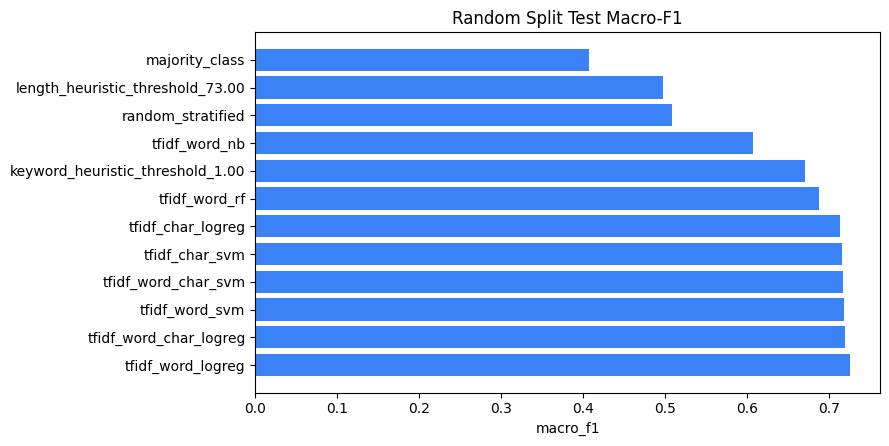

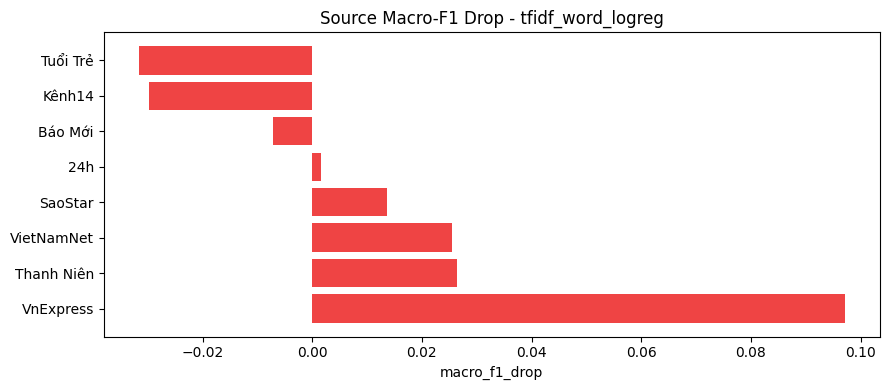

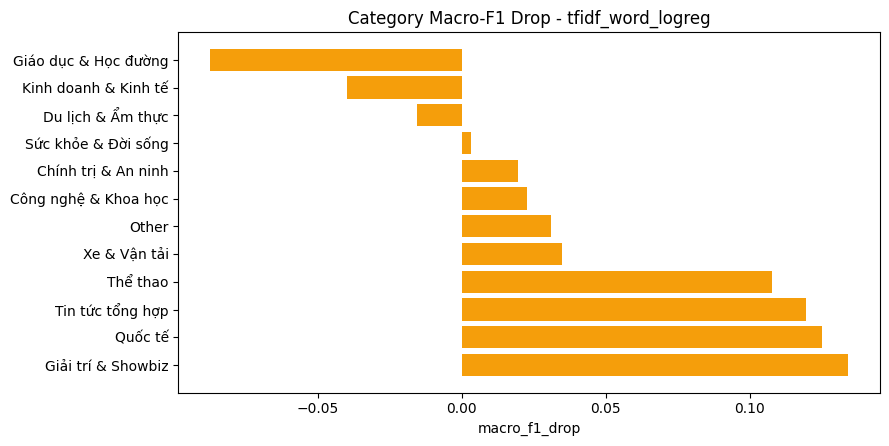

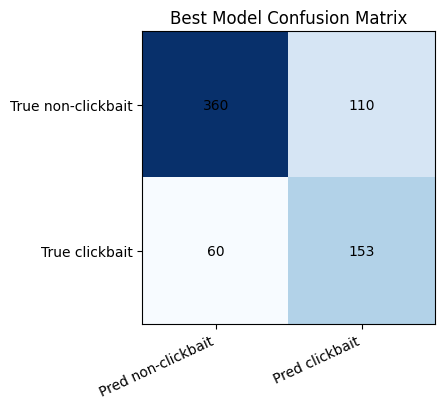

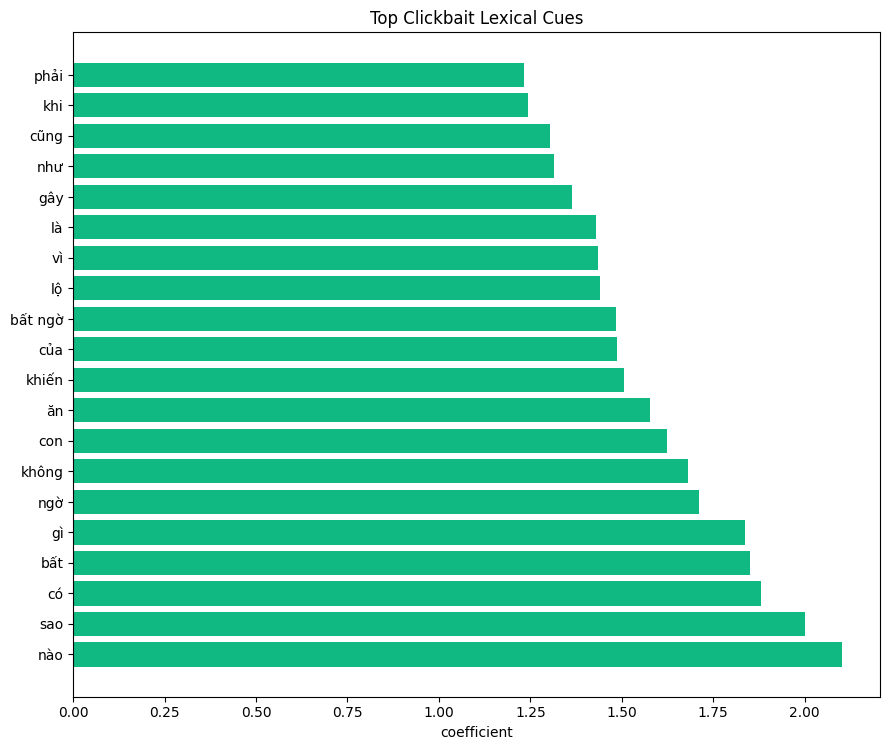

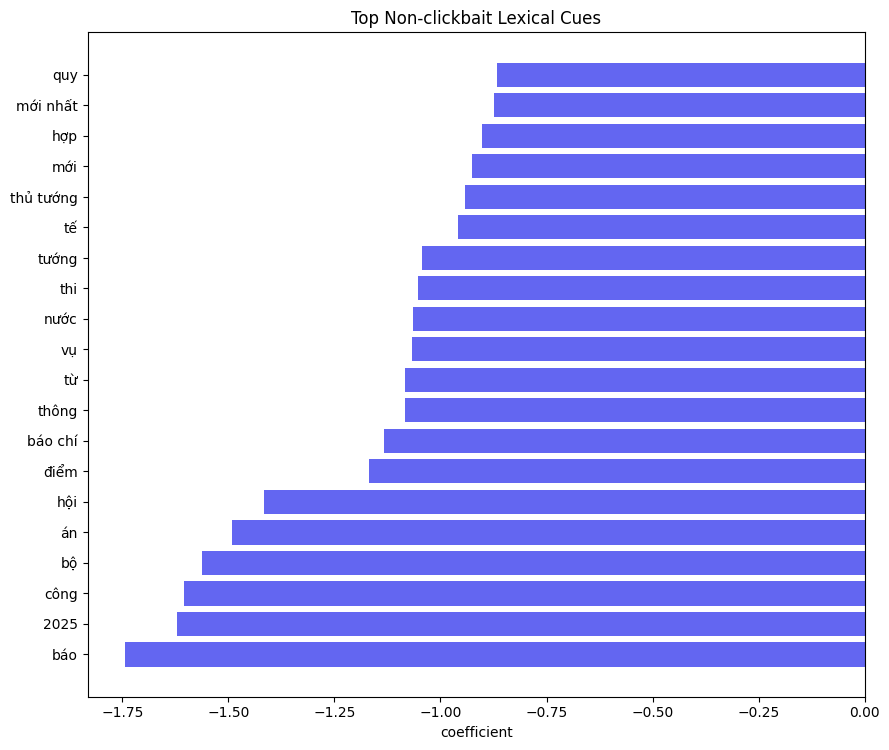

Saved figures:
  - /content/figures/best_model_confusion_matrix.png
  - /content/figures/domain_drop_by_category.png
  - /content/figures/domain_drop_by_source.png
  - /content/figures/random_split_macro_f1.png
  - /content/figures/top_clickbait_features.png
  - /content/figures/top_non_clickbait_features.png


In [27]:
# ============== VISUALIZATION ====================

from pathlib import Path
from IPython.display import display, Image

!mkdir -p /content/figures

FIG_DIR = Path('/content/figures')

def save_barh(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    title: str,
    path: Path,
    color: str = '#4C78A8',
    show: bool = True,
):
    plot_df = df.copy()

    fig, ax = plt.subplots(figsize=(9, max(4, 0.38 * len(plot_df))))

    ax.barh(plot_df[y_col].astype(str), plot_df[x_col], color=color)

    ax.set_xlabel(x_col)
    ax.set_title(title)

    ax.invert_yaxis()

    plt.tight_layout()

    # Save PNG
    plt.savefig(path, dpi=160, bbox_inches='tight')

    # Show directly in Colab output
    if show:
        plt.show()

    plt.close(fig)


# =========================================================
# Random split Macro-F1
# =========================================================

fig_random = random_split_leaderboard.sort_values(
    'macro_f1',
    ascending=True,
).copy()

save_barh(
    fig_random,
    x_col='macro_f1',
    y_col='model_name',
    title='Random Split Test Macro-F1',
    path=FIG_DIR / 'random_split_macro_f1.png',
    color='#3B82F6',
)


# =========================================================
# Domain drop plots
# =========================================================

best_logreg_name = (
    random_split_leaderboard[
        random_split_leaderboard['model_name'].str.contains('logreg')
    ]
    .iloc[0]['model_name']
)

source_plot = (
    source_drop[source_drop['model_name'] == best_logreg_name]
    .sort_values('macro_f1_drop', ascending=True)
)

category_plot = (
    category_drop[category_drop['model_name'] == best_logreg_name]
    .sort_values('macro_f1_drop', ascending=True)
)

save_barh(
    source_plot,
    'macro_f1_drop',
    'domain_name',
    f'Source Macro-F1 Drop - {best_logreg_name}',
    FIG_DIR / 'domain_drop_by_source.png',
    '#EF4444',
)

save_barh(
    category_plot,
    'macro_f1_drop',
    'domain_name',
    f'Category Macro-F1 Drop - {best_logreg_name}',
    FIG_DIR / 'domain_drop_by_category.png',
    '#F59E0B',
)


# =========================================================
# Confusion Matrix
# =========================================================

cm = confusion_matrix(
    best_model_error_table['y_true'],
    best_model_error_table['y_pred'],
    labels=[0, 1],
)

fig, ax = plt.subplots(figsize=(4.8, 4.2))

im = ax.imshow(cm, cmap='Blues')

ax.set_title('Best Model Confusion Matrix')

ax.set_xticks([0, 1])
ax.set_xticklabels(
    ['Pred non-clickbait', 'Pred clickbait'],
    rotation=25,
    ha='right'
)

ax.set_yticks([0, 1])
ax.set_yticklabels(
    ['True non-clickbait', 'True clickbait']
)

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha='center',
            va='center',
            color='black',
        )

plt.tight_layout()

plt.savefig(
    FIG_DIR / 'best_model_confusion_matrix.png',
    dpi=160,
    bbox_inches='tight'
)

plt.show()

plt.close(fig)


# =========================================================
# Feature cue figures
# =========================================================

top_clickbait = (
    feature_cue_summary[
        feature_cue_summary['direction'] == 'clickbait'
    ]
    .head(20)
    .sort_values('coefficient', ascending=True)
)

top_non_clickbait = (
    feature_cue_summary[
        feature_cue_summary['direction'] == 'non_clickbait'
    ]
    .head(20)
    .sort_values('coefficient', ascending=False)
)

save_barh(
    top_clickbait,
    'coefficient',
    'feature',
    'Top Clickbait Lexical Cues',
    FIG_DIR / 'top_clickbait_features.png',
    '#10B981',
)

save_barh(
    top_non_clickbait,
    'coefficient',
    'feature',
    'Top Non-clickbait Lexical Cues',
    FIG_DIR / 'top_non_clickbait_features.png',
    '#6366F1',
)


# =========================================================
# Print saved files
# =========================================================

print('Saved figures:')

for path in sorted(FIG_DIR.glob('*.png')):
    print(f'  - {path}')

In [24]:
# ====================== SUMMARY PHASE5 ======================
def fmt(x, digits: int = 4) -> str:
    if pd.isna(x):
        return 'NA'
    return f'{float(x):.{digits}f}'

best_random = random_split_leaderboard.iloc[0]
best_kfold = kfold_summary.iloc[0]
worst_source = source_robustness_summary.sort_values('macro_f1').iloc[0]
worst_category = category_robustness_summary.sort_values('macro_f1').iloc[0]
error_counts = best_model_error_table['error_type'].value_counts().to_dict()
manual_counts = manual_error_annotation_template['error_type'].value_counts().to_dict()

summary_lines = [
    '# Phase 5 Analysis Summary',
    '',
    '## Audit',
    '',
    f"- Audit passed: `{phase5_audit['audit_passed']}`",
    f"- Best model prediction rows: {phase5_audit['best_predictions_rows']}",
    f"- Feature rows: {phase5_audit['features_rows']}",
    '',
    '## Benchmark Synthesis',
    '',
    f"- Best random split model: `{best_random['model_name']}`",
    f"- Random-test Macro-F1: {fmt(best_random['macro_f1'])}",
    f"- Random-test Clickbait F1: {fmt(best_random['clickbait_f1'])}",
    f"- Best k-fold mean model: `{best_kfold['model_name']}`",
    f"- K-fold Macro-F1 mean: {fmt(best_kfold['macro_f1_mean'])}",
    f"- K-fold Macro-F1 std: {fmt(best_kfold['macro_f1_std'])}",
    '',
    '## Domain Robustness',
    '',
    f"- Hardest source-held-out case: `{worst_source['domain_name']}` with `{worst_source['model_name']}`",
    f"- Source-held-out Macro-F1: {fmt(worst_source['macro_f1'])}",
    f"- Source-held-out Clickbait F1: {fmt(worst_source['clickbait_f1'])}",
    f"- Hardest category-held-out case: `{worst_category['domain_name']}` with `{worst_category['model_name']}`",
    f"- Category-held-out Macro-F1: {fmt(worst_category['macro_f1'])}",
    f"- Category-held-out Clickbait F1: {fmt(worst_category['clickbait_f1'])}",
    '',
    '## Error Analysis',
    '',
    f"- Error type counts: `{error_counts}`",
    f"- Manual annotation sample counts: `{manual_counts}`",
    '',
    '## Outputs',
    '',
    '- `random_split_leaderboard.csv`',
    '- `kfold_summary.csv`',
    '- `domain_drop_summary.csv`',
    '- `best_model_error_table.csv`',
    '- `manual_error_annotation_template.csv`',
    '- `manual_error_taxonomy_guide.md`',
    '- `feature_cue_summary.csv`',
    '- `case_study_candidates.csv`',
]

phase5_summary_md = '\n'.join(summary_lines) + '\n'
(PHASE5_DIR / 'phase5_summary.md').write_text(phase5_summary_md, encoding='utf-8')
print(phase5_summary_md)

# Phase 5 Analysis Summary

## Audit

- Audit passed: `True`
- Best model prediction rows: 683
- Feature rows: 3414

## Benchmark Synthesis

- Best random split model: `tfidf_word_logreg`
- Random-test Macro-F1: 0.7259
- Random-test Clickbait F1: 0.6429
- Best k-fold mean model: `tfidf_word_char_logreg`
- K-fold Macro-F1 mean: 0.7464
- K-fold Macro-F1 std: 0.0048

## Domain Robustness

- Hardest source-held-out case: `VnExpress` with `tfidf_word_logreg`
- Source-held-out Macro-F1: 0.6288
- Source-held-out Clickbait F1: 0.4444
- Hardest category-held-out case: `Giải trí & Showbiz` with `tfidf_word_svm`
- Category-held-out Macro-F1: 0.5708
- Category-held-out Clickbait F1: 0.6573

## Error Analysis

- Error type counts: `{'TN': 360, 'TP': 153, 'FP': 110, 'FN': 60}`
- Manual annotation sample counts: `{'FN': 50, 'FP': 50}`

## Outputs

- `random_split_leaderboard.csv`
- `kfold_summary.csv`
- `domain_drop_summary.csv`
- `best_model_error_table.csv`
- `manual_error_annotation_template.csv`


In [26]:
# ========================= SANITY CHECK OUTPUTS =========================
expected_outputs = [
    'phase5_data_audit.json',
    'random_split_leaderboard.csv',
    'kfold_summary.csv',
    'domain_drop_summary.csv',
    'source_robustness_summary.csv',
    'category_robustness_summary.csv',
    'best_model_error_table.csv',
    'error_profile_by_source.csv',
    'error_profile_by_category.csv',
    'error_profile_by_surface_features.csv',
    'manual_error_annotation_template.csv',
    'manual_error_taxonomy_guide.md',
    'feature_cue_summary.csv',
    'case_study_candidates.csv',
    'phase5_summary.md',
]

missing_outputs = [name for name in expected_outputs if not (PHASE5_DIR / name).exists()]
print('Missing outputs:', missing_outputs)
print('Exported Phase 5 files:')
for path in sorted(PHASE5_DIR.glob('*')):
    print(f'  - {path}')

if missing_outputs:
    raise FileNotFoundError(f'Missing expected Phase 5 outputs: {missing_outputs}')

Missing outputs: []
Exported Phase 5 files:
  - /content/phase5/best_model_error_table.csv
  - /content/phase5/case_study_candidates.csv
  - /content/phase5/category_robustness_summary.csv
  - /content/phase5/domain_drop_summary.csv
  - /content/phase5/error_profile_by_category.csv
  - /content/phase5/error_profile_by_source.csv
  - /content/phase5/error_profile_by_surface_features.csv
  - /content/phase5/feature_cue_summary.csv
  - /content/phase5/kfold_summary.csv
  - /content/phase5/manual_error_annotation_template.csv
  - /content/phase5/manual_error_taxonomy_guide.md
  - /content/phase5/phase5_data_audit.json
  - /content/phase5/phase5_summary.md
  - /content/phase5/random_split_leaderboard.csv
  - /content/phase5/source_robustness_summary.csv
